### Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

### Data:

In [2]:
DATA_PATH = "tasas_BRL_COP_CHI_1993-2025.csv"
DATA_INDICADORES_PATH = "indicadores_colombia.xlsx"
DATA_GOLD_PATH = "gold_1993-2026.xlsx"
DATA_BITCOIN_PATH = "bitcoin_2010-2026.xlsx"

def load_csv(path):
    return pd.read_csv(path)


def load_xlsx(path):
    return pd.read_excel(io=path, sheet_name=None)

### Datos iniciales:

In [3]:
df_indicadores = load_xlsx(DATA_INDICADORES_PATH)

dfs_limpios = []

for nombre, df in df_indicadores.items():
    df = df.copy()
    
    # Estandarizar nombres
    df.columns = ["Date", "value"]
    
    # Convertir fecha
    df["Date"] = pd.to_datetime(df["Date"])
    
    # Renombrar la columna de valor con el nombre de la hoja
    df = df.rename(columns={"value": nombre})
    
    # Poner fecha como índice
    df = df.set_index("Date")
    
    dfs_limpios.append(df)

df_final = pd.concat(dfs_limpios, axis=1)

df_final.describe()

C:\Users\oscar\AppData\Local\Temp\ipykernel_12616\160693670.py:22: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_final = pd.concat(dfs_limpios, axis=1)


,COGNPIBY Index,COGNFCEY Index,COGNGCFY Index,ECOXCOS Index,GDCCPCOL Index,GDP CYOY Index,COCIPIBY Index,COCPIYOY Index,CPPRNATY Index,COPIIYOY Index,233.028 Index,COMRTRM1 Index,COOVIBR Index,COOVIBR1 Index,233.064 Index
count,80.000000,80.000000,80.000000,101.000000,33.000000,136.000000,80.000000,409.000000,309.000000,309.000000,413.000000,261.000000,4444.000000,3565.000000,401.000000
mean,3.667500,4.301250,4.228750,268.495842,4783.750427,2.594118,3.746250,8.821149,5.654822,5.075971,84.538838,2816.517471,5.698722,5.825825,29202.603491
std,4.217317,4.402976,11.892921,104.579694,2204.389296,1.991343,4.219183,7.010629,7.075036,5.301334,12.268393,863.079686,2.931363,3.059761,19706.714505
min,-16.700000,-14.300000,-43.300000,92.450000,1730.390900,-7.400000,-16.700000,1.490000,-6.430000,-4.081000,56.860000,1693.500000,1.614000,1.658000,7201.000000
25%,2.100000,2.575000,-0.700000,168.820000,2583.665800,1.975000,2.175000,3.800000,1.900000,1.654000,75.420000,1975.850000,3.626000,3.910000,9867.000000
50%,3.100000,4.150000,4.250000,295.640000,5250.973100,2.650000,3.350000,5.970000,4.700000,4.225000,81.940000,2674.000000,4.376500,4.420000,23479.000000
75%,6.125000,5.500000,10.350000,347.310000,6479.532200,3.500000,6.075000,10.210000,7.190000,6.797000,95.230000,3500.000000,8.514500,8.740000,46514.000000
max,18.400000,22.000000,42.000000,458.620000,8279.102500,12.400000,18.500000,28.360000,34.590000,23.448000,109.810000,4826.000000,12.353000,12.341000,65543.000000


In [40]:
df_bitcoin = load_xlsx(DATA_BITCOIN_PATH)["Sheet1"]

df_bitcoin["Date"] = pd.to_datetime(df_bitcoin["Date"])

df_bitcoin.tail(10)

,Date,Cierre
5050,2010-07-30,0.06
5051,2010-07-29,0.07
5052,2010-07-28,0.06
5053,2010-07-27,0.06
5054,2010-07-26,0.06
5055,2010-07-23,0.06
5056,2010-07-22,0.05
5057,2010-07-21,0.08
5058,2010-07-20,0.07
5059,2010-07-19,0.08


In [5]:
df_gold = load_xlsx(DATA_GOLD_PATH)["Sheet1"]

df_gold["Date"] = pd.to_datetime(df_gold["Date"])

df_gold.head(10)

,Date,Últ precio
0,2026-04-23,4694.14
1,2026-04-22,4739.90
2,2026-04-21,4720.04
3,2026-04-20,4820.66
4,2026-04-17,4830.34
5,2026-04-16,4790.06
6,2026-04-15,4791.04
7,2026-04-14,4841.75
8,2026-04-13,4740.31
9,2026-04-10,4749.75


In [6]:
df = load_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df.head(10)

,Date,Rate_BRL,Rate_CHI,Rate_COP
0,1993-01-01,0.0045,382.33,735.00
1,1993-01-04,0.0046,383.57,737.98
2,1993-01-05,0.0046,383.64,737.98
3,1993-01-06,0.0047,383.32,737.98
4,1993-01-07,0.0047,383.59,737.98
5,1993-01-08,0.0048,384.83,737.98
6,1993-01-11,0.0048,384.08,737.98
7,1993-01-12,0.0049,383.64,746.63
8,1993-01-13,0.0049,384.74,746.63
9,1993-01-14,0.0051,384.35,748.98


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8360 entries, 0 to 8359
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      8360 non-null   datetime64[us]
 1   Rate_BRL  8360 non-null   float64       
 2   Rate_CHI  8360 non-null   float64       
 3   Rate_COP  8360 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 261.4 KB


In [8]:
df[["Rate_BRL", "Rate_CHI", "Rate_COP"]].describe()

,Rate_BRL,Rate_CHI,Rate_COP
count,8360.000000,8360.000000,8360.000000
mean,2.678583,601.063057,2397.554470
std,1.501276,153.780174,998.289121
min,0.004500,368.750000,735.000000
25%,1.733475,482.320000,1802.500000
50%,2.271550,567.000000,2279.645000
75%,3.597350,690.807500,2989.482500
max,6.293100,1048.500000,5120.150000


In [9]:
df_1995_2000 = df[(df["Date"] >= "1995-01-01") & (df["Date"] < "2001-01-01")]

df_1995_2000[["Rate_BRL", "Rate_CHI", "Rate_COP"]].describe()

,Rate_BRL,Rate_CHI,Rate_COP
count,1565.000000,1565.000000,1565.000000
mean,1.300492,456.206000,1393.990326
std,0.383274,55.032121,428.917429
min,0.832000,368.750000,831.270000
25%,1.004000,411.850000,1034.500000
50%,1.116000,440.150000,1305.660000
75%,1.776000,503.150000,1748.000000
max,2.150000,580.350000,2243.000000


In [10]:
df_2000_2005 = df[(df["Date"] >= "2000-01-01") & (df["Date"] < "2006-01-01")]

df_2000_2005[["Rate_BRL", "Rate_CHI", "Rate_COP"]].describe()

,Rate_BRL,Rate_CHI,Rate_COP
count,1565.000000,1565.000000,1565.000000
mean,2.590513,620.605003,2454.338843
std,0.514556,67.472815,277.361410
min,1.719000,501.050000,1877.500000
25%,2.254500,570.550000,2279.000000
50%,2.586500,609.150000,2338.000000
75%,2.920500,677.550000,2717.000000
max,3.950500,759.750000,2980.000000


In [11]:
df_2005_2010 = df[(df["Date"] >= "2005-01-01") & (df["Date"] < "2011-01-01")]

df_2005_2010[["Rate_BRL", "Rate_CHI", "Rate_COP"]].describe()

,Rate_BRL,Rate_CHI,Rate_COP
count,1550.000000,1550.000000,1550.000000
mean,2.025936,534.123852,2130.120316
std,0.282842,41.685199,219.068511
min,1.560000,429.550000,1655.030000
25%,1.767250,513.285000,1941.500000
50%,2.023350,530.100000,2157.700000
75%,2.230650,547.650000,2312.450000
max,2.764000,682.750000,2644.000000


In [12]:
df_2010_2015 = df[(df["Date"] >= "2010-01-01") & (df["Date"] < "2016-01-01")]

df_2010_2015[["Rate_BRL", "Rate_CHI", "Rate_COP"]].describe()

,Rate_BRL,Rate_CHI,Rate_COP
count,1488.000000,1488.000000,1488.000000
mean,2.203640,533.637151,2027.827856
std,0.596668,66.180352,359.043897
min,1.539100,455.660000,1748.500000
25%,1.763725,481.670000,1813.500000
50%,2.030300,509.875000,1895.770000
75%,2.356800,564.007500,1992.567500
max,4.179000,715.130000,3351.050000


In [13]:
df_2015_2020 = df[(df["Date"] >= "2015-01-01") & (df["Date"] < "2021-01-01")]

df_2015_2020[["Rate_BRL", "Rate_CHI", "Rate_COP"]].describe()

,Rate_BRL,Rate_CHI,Rate_COP
count,1474.000000,1474.000000,1474.000000
mean,3.796949,686.706696,3114.616201
std,0.722529,59.883197,351.461202
min,2.572800,587.190000,2355.020000
25%,3.238550,648.735000,2908.615000
50%,3.721550,672.420000,3039.650000
75%,4.046400,711.497500,3319.752500
max,5.887000,867.520000,4106.380000


In [14]:
df_2020_2025 = df[(df["Date"] >= "2020-01-01") & (df["Date"] <= "2026-01-01")]

df_2020_2025[["Rate_BRL", "Rate_CHI", "Rate_COP"]].describe()

,Rate_BRL,Rate_CHI,Rate_COP
count,1471.000000,1471.000000,1471.000000
mean,5.282185,860.666241,4024.198287
std,0.353374,82.112260,346.379611
min,4.024000,694.780000,3246.880000
25%,5.055950,795.400000,3800.190000
50%,5.297400,858.800000,3964.070000
75%,5.528250,938.190000,4183.015000
max,6.293100,1048.500000,5120.150000


### Plot:

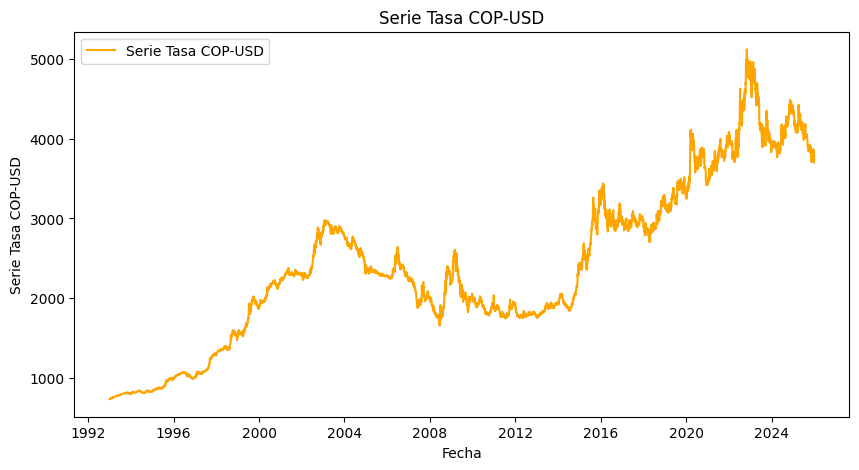

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Rate_COP"], label='Serie Tasa COP-USD', color='orange')

plt.title('Serie Tasa COP-USD')
plt.xlabel('Fecha')
plt.ylabel('Serie Tasa COP-USD')
plt.legend()
plt.show()

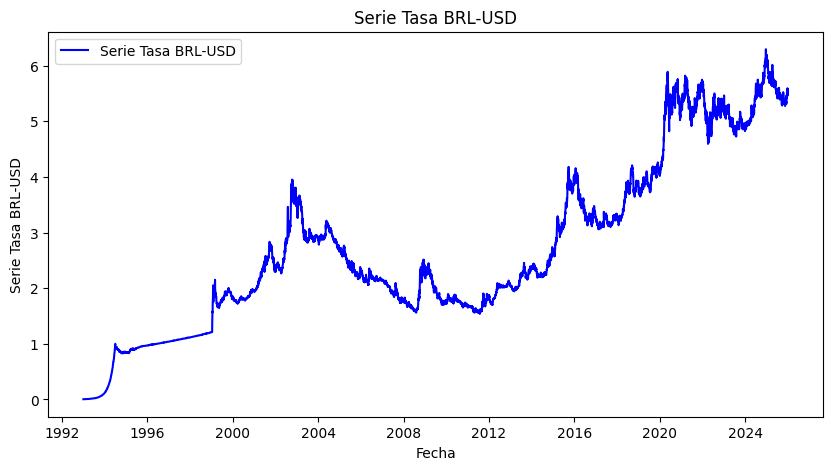

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Rate_BRL"], label='Serie Tasa BRL-USD', color='blue')

plt.title('Serie Tasa BRL-USD')
plt.xlabel('Fecha')
plt.ylabel('Serie Tasa BRL-USD')
plt.legend()
plt.show()

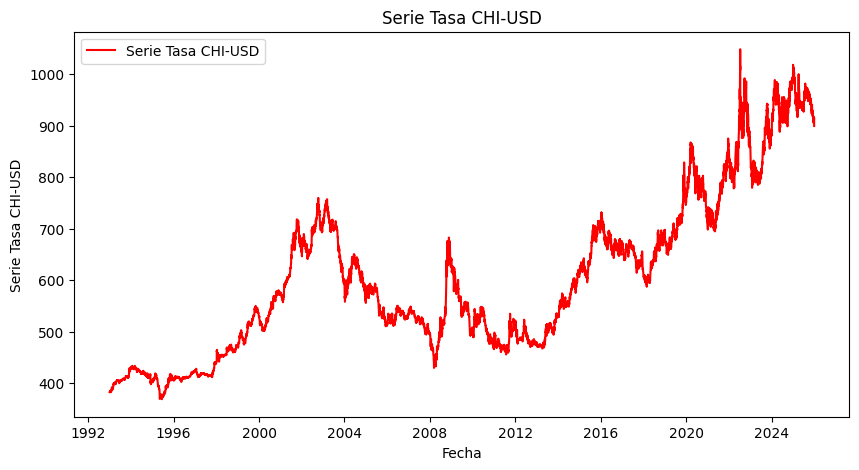

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Rate_CHI"], label='Serie Tasa CHI-USD', color='red')

plt.title('Serie Tasa CHI-USD')
plt.xlabel('Fecha')
plt.ylabel('Serie Tasa CHI-USD')
plt.legend()
plt.show()

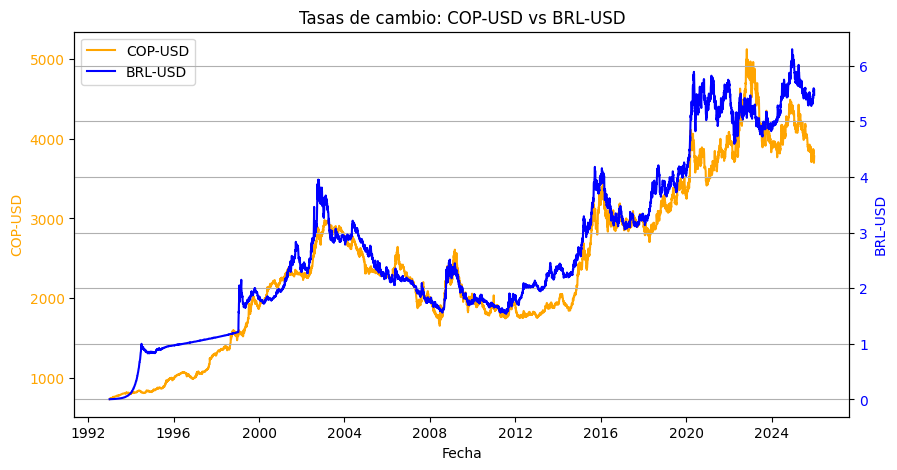

In [18]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# COP-USD (eje izquierdo)
ax1.plot(df["Date"], df["Rate_COP"], color="orange", label="COP-USD")
ax1.set_ylabel("COP-USD", color="orange")
ax1.tick_params(axis="y", labelcolor="orange")

# BRL-USD (eje derecho)
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Rate_BRL"], color="blue", label="BRL-USD")
ax2.set_ylabel("BRL-USD", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

ax1.set_xlabel("Fecha")
plt.title("Tasas de cambio: COP-USD vs BRL-USD")

# Leyenda combinada
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(True)
plt.show()

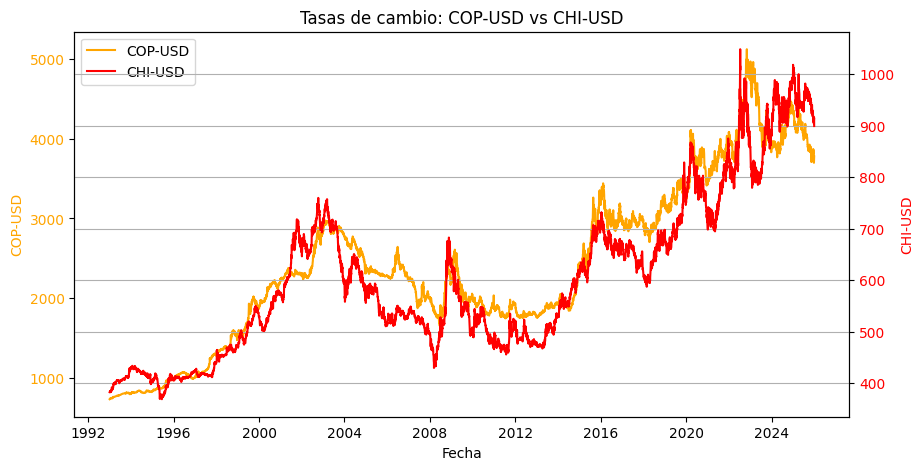

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# COP-USD (eje izquierdo)
ax1.plot(df["Date"], df["Rate_COP"], color="orange", label="COP-USD")
ax1.set_ylabel("COP-USD", color="orange")
ax1.tick_params(axis="y", labelcolor="orange")

# CHI-USD (eje derecho)
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Rate_CHI"], color="red", label="CHI-USD")
ax2.set_ylabel("CHI-USD", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_xlabel("Fecha")
plt.title("Tasas de cambio: COP-USD vs CHI-USD")

# Leyenda combinada
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(True)
plt.show()

### Union Gold + Exchange Rates (Necesaria imputacion de datos faltantes para Gold)

In [32]:
df_rates_gold = df[["Date", "Rate_COP", "Rate_BRL", "Rate_CHI"]].copy()

df_rates_gold = pd.merge(df_rates_gold, df_gold[["Date", "Últ precio"]], on="Date", how="left")

df_rates_gold.rename(columns={'Últ precio': 'Gold'}, inplace=True)

df_rates_gold.describe()

,Date,Rate_COP,Rate_BRL,Rate_CHI,Gold
count,8360,8360.000000,8360.000000,8360.000000,8352.000000
mean,2009-03-31 21:27:02.583732,2397.554470,2.678583,601.063057,1020.870829
min,1993-01-01 00:00:00,735.000000,0.004500,368.750000,252.550000
25%,2001-01-04 18:00:00,1802.500000,1.733475,482.320000,378.750000
50%,2009-01-26 12:00:00,2279.645000,2.271550,567.000000,925.100000
75%,2017-06-07 06:00:00,2989.482500,3.597350,690.807500,1433.542500
max,2025-12-30 00:00:00,5120.150000,6.293100,1048.500000,4533.210000
std,NaN,998.289121,1.501276,153.780174,741.906257


In [33]:
df_rates_gold["Gold"] = df_rates_gold["Gold"].interpolate(method="linear")

df_rates_gold.describe()

,Date,Rate_COP,Rate_BRL,Rate_CHI,Gold
count,8360,8360.000000,8360.000000,8360.000000,8359.000000
mean,2009-03-31 21:27:02.583732,2397.554470,2.678583,601.063057,1020.667656
min,1993-01-01 00:00:00,735.000000,0.004500,368.750000,252.550000
25%,2001-01-04 18:00:00,1802.500000,1.733475,482.320000,378.750000
50%,2009-01-26 12:00:00,2279.645000,2.271550,567.000000,925.100000
75%,2017-06-07 06:00:00,2989.482500,3.597350,690.807500,1432.790000
max,2025-12-30 00:00:00,5120.150000,6.293100,1048.500000,4533.210000
std,NaN,998.289121,1.501276,153.780174,741.798479


In [34]:
df_rates_gold["Gold"] = df_rates_gold["Gold"].bfill()

df_rates_gold.describe()

,Date,Rate_COP,Rate_BRL,Rate_CHI,Gold
count,8360,8360.000000,8360.000000,8360.000000,8360.000000
mean,2009-03-31 21:27:02.583732,2397.554470,2.678583,601.063057,1020.585100
min,1993-01-01 00:00:00,735.000000,0.004500,368.750000,252.550000
25%,2001-01-04 18:00:00,1802.500000,1.733475,482.320000,378.750000
50%,2009-01-26 12:00:00,2279.645000,2.271550,567.000000,925.040000
75%,2017-06-07 06:00:00,2989.482500,3.597350,690.807500,1432.495000
max,2025-12-30 00:00:00,5120.150000,6.293100,1048.500000,4533.210000
std,NaN,998.289121,1.501276,153.780174,741.792513


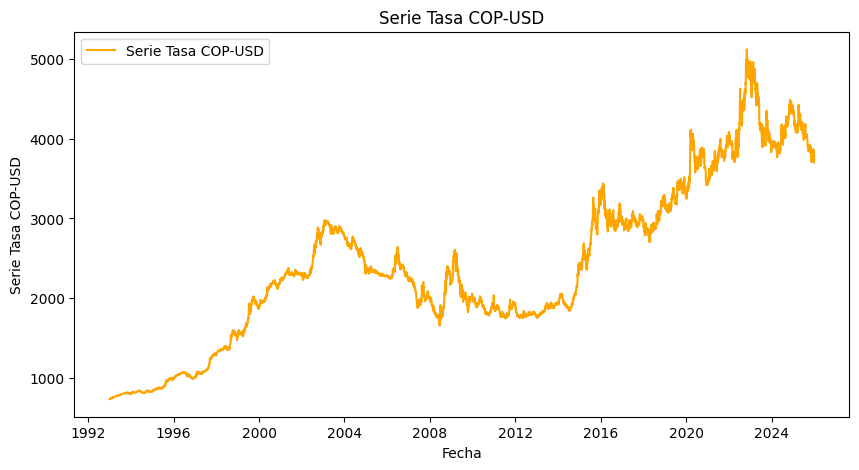

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(df_rates_gold["Date"], df_rates_gold["Rate_COP"], label='Serie Tasa COP-USD', color='orange')

plt.title('Serie Tasa COP-USD')
plt.xlabel('Fecha')
plt.ylabel('Serie Tasa COP-USD')
plt.legend()
plt.show()

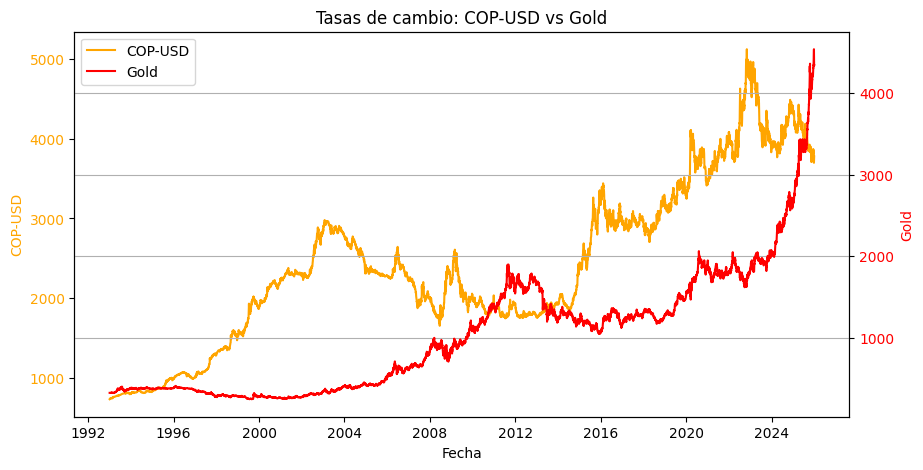

In [36]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# COP-USD (eje izquierdo)
ax1.plot(df_rates_gold["Date"], df_rates_gold["Rate_COP"], color="orange", label="COP-USD")
ax1.set_ylabel("COP-USD", color="orange")
ax1.tick_params(axis="y", labelcolor="orange")

# Gold (eje derecho)
ax2 = ax1.twinx()
ax2.plot(df_rates_gold["Date"], df_rates_gold["Gold"], color="red", label="Gold")
ax2.set_ylabel("Gold", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_xlabel("Fecha")
plt.title("Tasas de cambio: COP-USD vs Gold")

# Leyenda combinada
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(True)
plt.show()

In [37]:
col = "Rate_COP"

df_rates_gold = df_rates_gold[[c for c in df_rates_gold.columns if c != col] + [col]]

In [38]:
df_rates_gold.to_csv("data_rates_gold.csv", index=False)

### Union Bitcoin + Rates (imputacion de valores faltantes)

In [45]:
df_rates_bitcoin = df[["Date", "Rate_COP", "Rate_BRL", "Rate_CHI"]].copy()

df_rates_bitcoin = df_rates_bitcoin[df_rates_bitcoin["Date"] >= "2011-01-01"]

df_rates_bitcoin = pd.merge(df_rates_bitcoin, df_bitcoin[["Date", "Cierre"]], on="Date", how="left")

df_rates_bitcoin.rename(columns={'Cierre': 'Bitcoin'}, inplace=True)

df_rates_bitcoin.describe()

,Date,Rate_COP,Rate_BRL,Rate_CHI,Bitcoin
count,3679,3679.000000,3679.000000,3679.000000,3672.000000
mean,2018-06-29 20:51:43.886925,3111.217714,3.831601,702.010658,20287.314458
min,2011-01-03 00:00:00,1748.500000,1.539100,455.660000,0.300000
25%,2014-10-04 12:00:00,2047.500000,2.435750,591.235000,326.287500
50%,2018-07-10 00:00:00,3116.150000,3.813800,681.480000,6396.330000
75%,2022-03-29 12:00:00,3891.540000,5.180100,814.600000,29465.365000
max,2025-12-30 00:00:00,5120.150000,6.293100,1048.500000,125260.810000
std,NaN,901.910921,1.361748,155.029162,29853.085139


In [47]:
df_rates_bitcoin["Bitcoin"] = df_rates_bitcoin["Bitcoin"].interpolate(method="linear")

df_rates_bitcoin.describe()

,Date,Rate_COP,Rate_BRL,Rate_CHI,Bitcoin
count,3679,3679.000000,3679.000000,3679.000000,3679.000000
mean,2018-06-29 20:51:43.886925,3111.217714,3.831601,702.010658,20248.978460
min,2011-01-03 00:00:00,1748.500000,1.539100,455.660000,0.300000
25%,2014-10-04 12:00:00,2047.500000,2.435750,591.235000,322.550000
50%,2018-07-10 00:00:00,3116.150000,3.813800,681.480000,6386.600000
75%,2022-03-29 12:00:00,3891.540000,5.180100,814.600000,29437.925000
max,2025-12-30 00:00:00,5120.150000,6.293100,1048.500000,125260.810000
std,NaN,901.910921,1.361748,155.029162,29837.589679


In [48]:
col = "Rate_COP"

df_rates_bitcoin = df_rates_bitcoin[[c for c in df_rates_bitcoin.columns if c != col] + [col]]

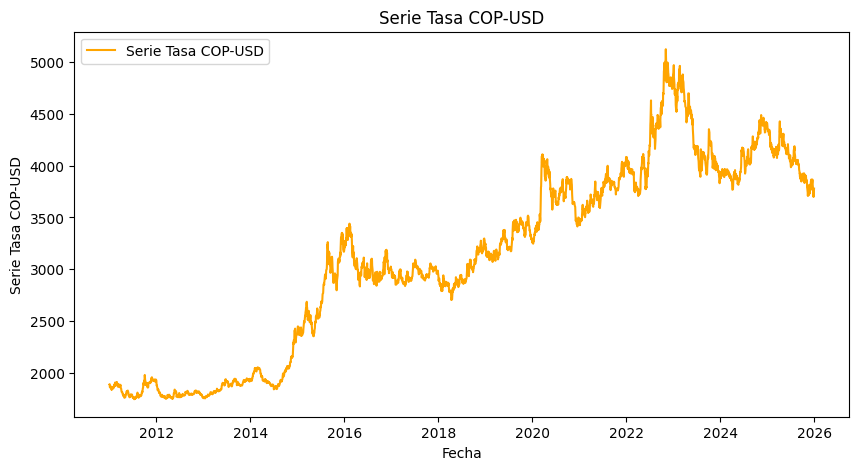

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(df_rates_bitcoin["Date"], df_rates_bitcoin["Rate_COP"], label='Serie Tasa COP-USD', color='orange')

plt.title('Serie Tasa COP-USD')
plt.xlabel('Fecha')
plt.ylabel('Serie Tasa COP-USD')
plt.legend()
plt.show()

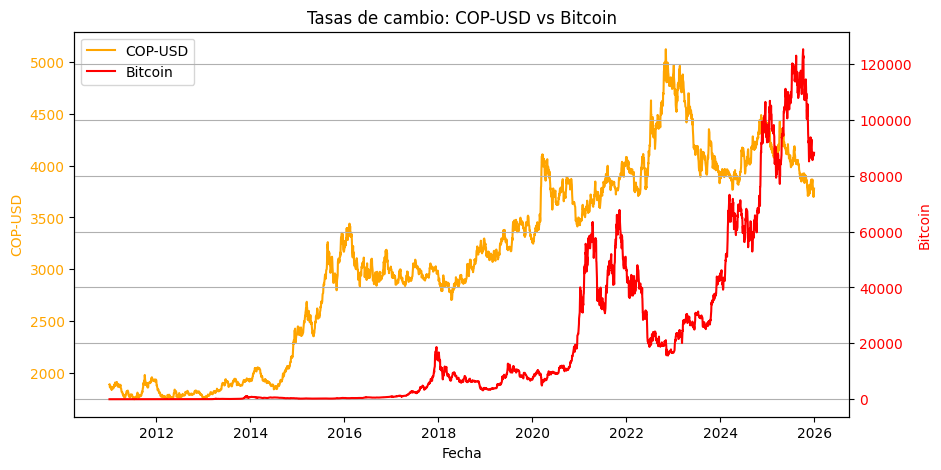

In [51]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# COP-USD (eje izquierdo)
ax1.plot(df_rates_bitcoin["Date"], df_rates_bitcoin["Rate_COP"], color="orange", label="COP-USD")
ax1.set_ylabel("COP-USD", color="orange")
ax1.tick_params(axis="y", labelcolor="orange")

# Gold (eje derecho)
ax2 = ax1.twinx()
ax2.plot(df_rates_bitcoin["Date"], df_rates_bitcoin["Bitcoin"], color="red", label="Bitcoin")
ax2.set_ylabel("Bitcoin", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_xlabel("Fecha")
plt.title("Tasas de cambio: COP-USD vs Bitcoin")

# Leyenda combinada
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(True)
plt.show()

In [52]:
df_rates_bitcoin.to_csv("data_rates_bitcoin.csv", index=False)